### Inference 2D

In [16]:
import os
import subprocess
import shutil
import gc
from pathlib import Path

import SimpleITK as sitk
import numpy as np
import tifffile
import mrcfile
import psutil
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1) SET nnU-NET ENVIRONMENT VARIABLES
# -----------------------------------------------------------------------------
os.environ['nnUNet_raw']          = '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_preprocessed'
os.environ['nnUNet_results']      = '/media/home/DATA10TB/MITOCHONDRIA/nnUNet_results'

# -----------------------------------------------------------------------------
# 2) GLOBAL STATE
# -----------------------------------------------------------------------------
rgb_stack = None

# -----------------------------------------------------------------------------
# 3) HELPERS
# -----------------------------------------------------------------------------
def print_memory_usage(message):
    proc = psutil.Process()
    mem_gb = proc.memory_info().rss / (1024 ** 3)
    print(f"{message} – memory: {mem_gb:.2f} GB")

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def clear_dir(path):
    if os.path.exists(path):
        for fn in os.listdir(path):
            fp = os.path.join(path, fn)
            if os.path.isfile(fp) or os.path.islink(fp):
                os.remove(fp)
            else:
                shutil.rmtree(fp)

def display_slice(slice_2d):
    """Show one 2D slice plus its histogram side by side."""
    slice_2d = slice_2d.astype(np.uint8)
    plt.figure(figsize=(10,5))
    ax1 = plt.subplot(1,2,1)
    ax1.imshow(slice_2d, cmap='gray')
    ax1.axis('off'); ax1.set_title('Middle slice')
    ax2 = plt.subplot(1,2,2)
    ax2.hist(slice_2d.ravel(), bins=256)
    ax2.set_title('Histogram')
    plt.tight_layout()
    plt.show()

def load_stack(fp, mcr=True):
    """Load a 3D stack; if TIFF has >1 channel, take channel index 1."""
    if mcr:
        with mrcfile.open(fp, 'r') as m:
            stack = m.data
    else:
        with tifffile.TiffFile(fp) as tif:
            arr = tif.asarray()
            if arr.ndim == 4:
                stack = arr[...,1] if arr.shape[-1] > 1 else arr[...,0]
            else:
                stack = arr
    # correct signed-8 data
    if np.issubdtype(stack.dtype, np.integer) and stack.dtype.itemsize == 1 and np.any(stack < 0):
        stack = (stack.astype(np.int16) + 256).astype(np.uint8)
    return stack

# -----------------------------------------------------------------------------
# 4) nnU-NET PIPELINE FUNCTIONS
# -----------------------------------------------------------------------------
def create_2d_slices(stack, out_dir):
    ensure_dir(out_dir); clear_dir(out_dir)
    z,_,_ = stack.shape
    for i in range(z):
        arr = stack[i].astype(np.float32)[None]  # shape (1,H,W)
        img = sitk.GetImageFromArray(arr)
        sitk.WriteImage(img, os.path.join(out_dir, f"slice_2d_{i:04d}_0000.nii.gz"))

def run_2d_prediction(slices_dir, out_dir, d_id, fold,
                      trainer='nnUNetTrainer_100epochs',
                      save_probabilities=True):
    """
    Call nnUNetv2_predict for 2D slices quietly (no flooding progress bars),
    and raise an error if it fails.
    """
    ensure_dir(out_dir)
    clear_dir(out_dir)

    cmd = [
        'nnUNetv2_predict',
        '-i', str(slices_dir),
        '-o', str(out_dir),
        '-d', str(d_id),
        '-f', str(fold),
        '-tr', trainer,
        '-c', '2d',
    ]
    if save_probabilities:
        cmd.append('--save_probabilities')

    try:
        # redirect both stdout and stderr to DEVNULL to silence everything
        subprocess.run(cmd,
                       stdout=subprocess.DEVNULL,
                       stderr=subprocess.DEVNULL,
                       check=True)
    except subprocess.CalledProcessError as e:
        # if it fails, re-raise with a concise message
        raise RuntimeError(f"nnUNetv2_predict (2D) failed (exit code {e.returncode})")

def reconstruct_2d_stack(orig, out_dir, save_probabilities=True):
    """Load each .npz, build full-volume seg or prob map into rgb_stack blue channel."""
    global rgb_stack
    z, y, x = orig.shape
    recon = np.zeros((z, y, x), dtype=np.float32)
    for fname in sorted(os.listdir(out_dir)):
        if fname.endswith('.npz'):
            idx = int(Path(fname).stem.split('_')[-1])
            data = np.load(os.path.join(out_dir, fname))
            recon[idx] = data[data.files[0]][1]
    if save_probabilities:
        mask = (recon * 255).clip(0,255).astype(np.uint8)
    else:
        mask = (recon > 0.5).astype(np.uint8) * 255
    rgb_stack[...,2] = mask  # blue channel

def process_file(fp, slices_dir, out_dir, d_id, fold, save_probabilities):
    """Run load→slice→predict→reconstruct→save for one file."""
    global rgb_stack
    stack = load_stack(fp, mcr=fp.lower().endswith('.mrc'))
    rgb_stack = np.zeros((*stack.shape, 3), dtype=np.uint8)
    rgb_stack[...,1] = stack  # original in green

    create_2d_slices(stack, slices_dir)
    run_2d_prediction(slices_dir, out_dir, d_id, fold,
                      save_probabilities=save_probabilities)
    reconstruct_2d_stack(stack, out_dir, save_probabilities)

    # build overlay filename by combining stem + suffix
    p = Path(fp)
    overlay_fp = p.parent / f"{p.stem}_2D_OVERLAY.tiff"
    tifffile.imsave(str(overlay_fp), rgb_stack, photometric='rgb')
    print(f"→ Saved overlay: {overlay_fp}")

# -----------------------------------------------------------------------------
# 5) MAIN LOOP: LIST FILES, SHOW SLICE, PROCESS WITH PROGRESS
# -----------------------------------------------------------------------------
def traverse(top_dir, slices_dir, out_dir, d_id, fold, save_probabilities):
    print("Scanning for .mrc/.tif files…")
    files = []
    for root, _, fns in os.walk(top_dir):
        for fn in fns:
            if fn.lower().endswith(('.mrc','.tif','.tiff')):
                fp = os.path.join(root, fn)
                files.append(fp)
                print(f"Found: {fp}")
    total = len(files)
    print(f"Total files to process: {total}")
    if input("Continue? (yes/no): ").lower() != 'yes':
        return

    for idx, fp in enumerate(files, start=1):
        print(f"\n=== [{idx}/{total}] {fp} ===")
        stack = load_stack(fp, mcr=fp.lower().endswith('.mrc'))
        display_slice(stack[stack.shape[0]//2])
        process_file(fp, slices_dir, out_dir, d_id, fold, save_probabilities)
        if idx % 10 == 0 or idx == total:
            print(f"Processed {idx}/{total} files")

    print_memory_usage("All done")

Scanning for .mrc/.tif files…
Found: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT051_A1_170428-a-1_OVERLAY-1-128.tif
Found: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT055_160610b-a_OVERLAY-1-128.tif
Found: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT055_area2_160616-a_OVERLAY-1-128.tif
Found: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT073_160715-a_OVERLAY-327-454.tif
Found: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT45_area1_170623-a_OVERLAY-129-257.tif
Total files to process: 5


Continue? (yes/no):  yes



=== [1/5] /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT051_A1_170428-a-1_OVERLAY-1-128.tif ===


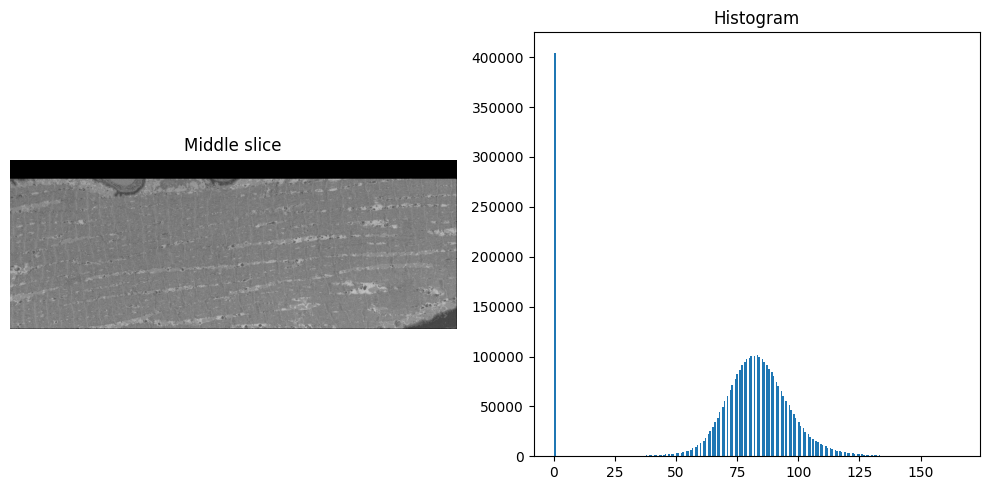

/tmp/ipykernel_155389/1986401873.py:150: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(str(overlay_fp), rgb_stack, photometric='rgb')


→ Saved overlay: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT051_A1_170428-a-1_OVERLAY-1-128_2D_OVERLAY.tiff

=== [2/5] /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT055_160610b-a_OVERLAY-1-128.tif ===


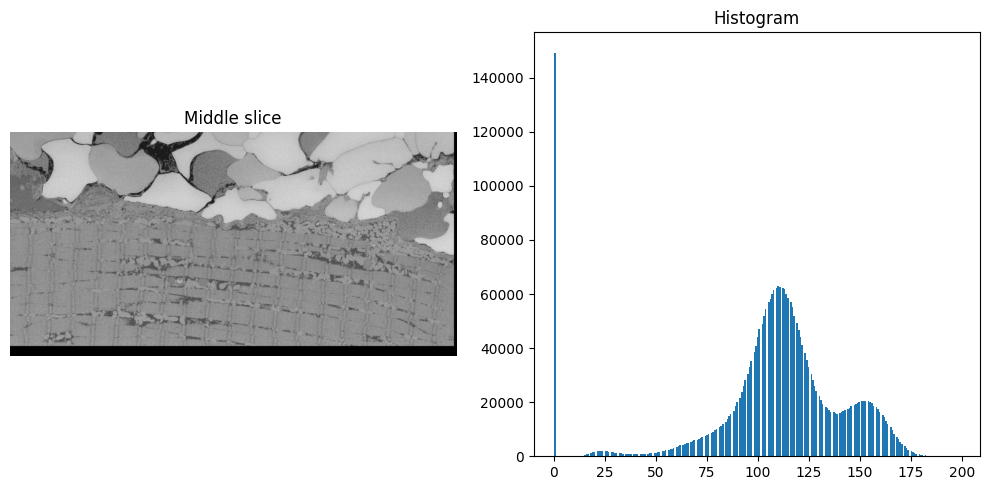

/tmp/ipykernel_155389/1986401873.py:150: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(str(overlay_fp), rgb_stack, photometric='rgb')


→ Saved overlay: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT055_160610b-a_OVERLAY-1-128_2D_OVERLAY.tiff

=== [3/5] /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT055_area2_160616-a_OVERLAY-1-128.tif ===


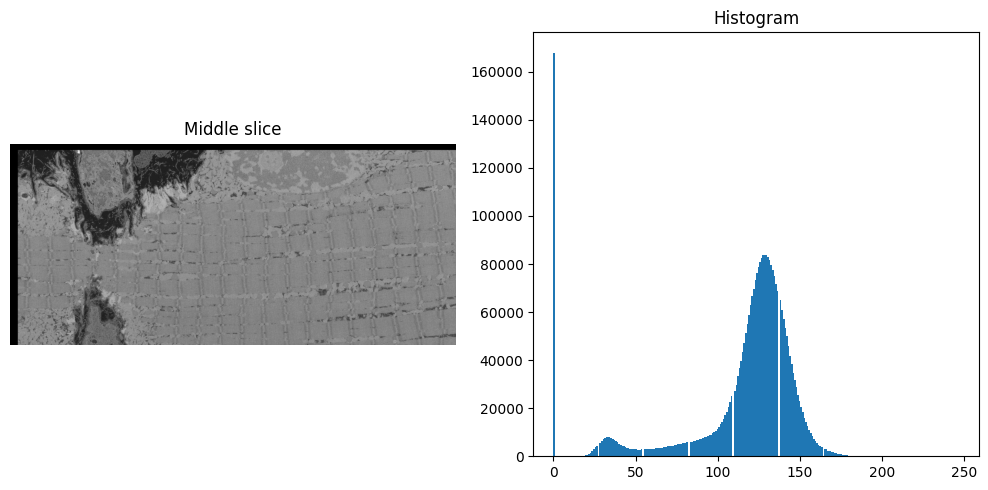

/tmp/ipykernel_155389/1986401873.py:150: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(str(overlay_fp), rgb_stack, photometric='rgb')


→ Saved overlay: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT055_area2_160616-a_OVERLAY-1-128_2D_OVERLAY.tiff

=== [4/5] /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT073_160715-a_OVERLAY-327-454.tif ===


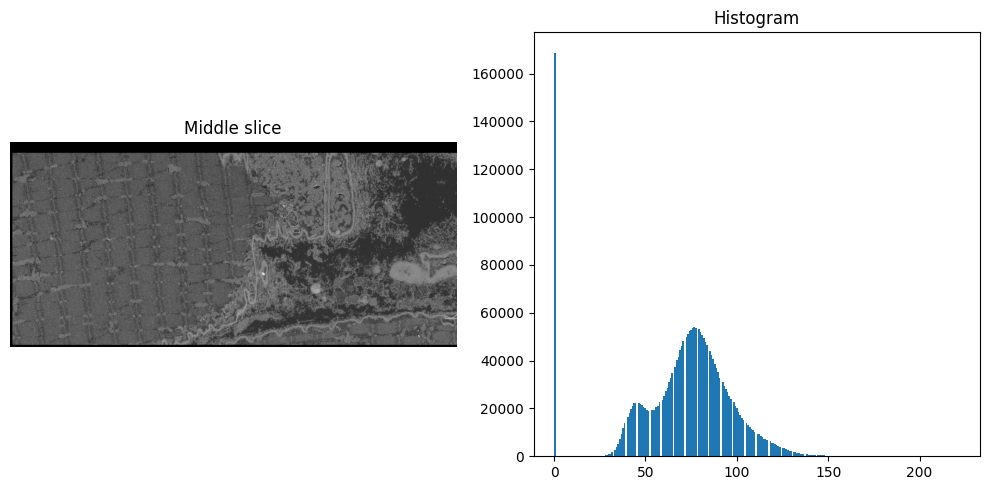

/tmp/ipykernel_155389/1986401873.py:150: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(str(overlay_fp), rgb_stack, photometric='rgb')


→ Saved overlay: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT073_160715-a_OVERLAY-327-454_2D_OVERLAY.tiff

=== [5/5] /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT45_area1_170623-a_OVERLAY-129-257.tif ===


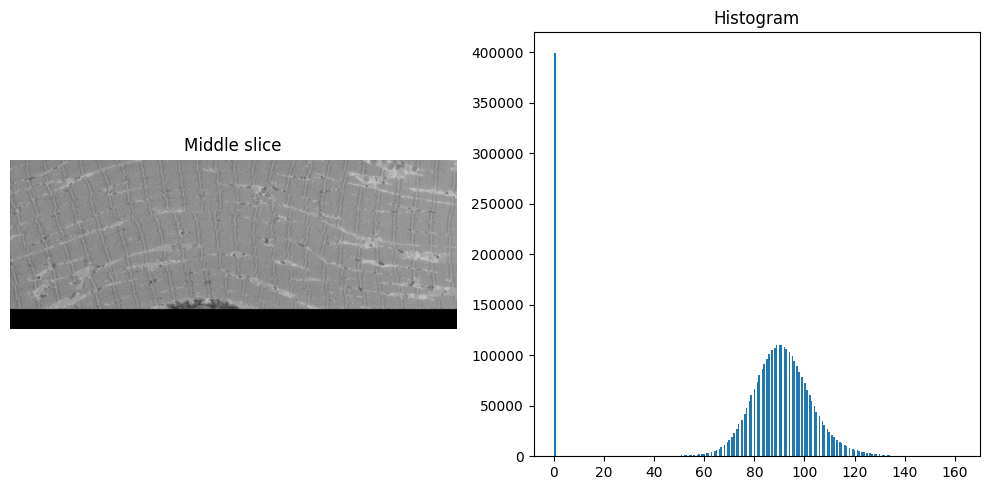

/tmp/ipykernel_155389/1986401873.py:150: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  tifffile.imsave(str(overlay_fp), rgb_stack, photometric='rgb')


→ Saved overlay: /media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN/b3GT45_area1_170623-a_OVERLAY-129-257_2D_OVERLAY.tiff
Processed 5/5 files
All done – memory: 2.78 GB


In [17]:
top_directory     = '/media/home/DATA10TB/MITOCHONDRIA/GT-4-16/TEST_TRAIN'
chunk_directory   = './slices_2d'
output_directory  = './predictions_2d'
dataset_id        = 105
fold              = 0
save_probabilities= True

traverse(
    top_directory,
    chunk_directory,
    output_directory,
    dataset_id,
    fold,
    save_probabilities
)